일반화 가능성 증가
과적합 가능성 감소

이미 일반화 한 모형에 대해서는 할 필요 없고
과적합 떴을 때...


의사결정트리를 사용하는 가장 대표적인 배깅모델

의사결정나무를 쪼개서..
앙상블 활용


수집,전처리,탐색적데이터분석,추론




년도 시간 단이 데이터가 다르면,,,, group by 로 평균치로 돌리거나 해야함....



데이터 변환....로그변환..더미변환 > 촤조 엑셀 저장...
분석 모형을 각자 따로 돌려

오늘은 그 이후에 어떻게 하는거야



실전에서는 하나로 어떻게 합치는가....!




배깅 후보 선정~

단순히 성능으로 판단 x
과적합 떴을 떄 완화하는 역할

분산 감소를 통한 일반화가 목적

휴리스틱....

사람들의 경험들이 쌓여서 경험적 지식인거...


선형, 커널은 대상이 아님...
knn,트리만

학습 완료된 모델을 파일로 저장,,,,, 머신러닝 관련 결과를 다 가지고 있는거.... 



저장된 모듈 불러오기~~
배깅 >하나의모델을 여려번 수행

부트스트랩 > 복원 추출



배깅 --> 랜덤 포레스트
부스팅 --> xgb boost,light gbm ,catboost




ex) 결과 잘 나온게
rf (배깅)
xgboost (부스팅)
sgd (단일)
linear (딴일)
en (딴일)

>> 이 5개로 보팅을 해


# [LAB 08] 지도학습 > 예측 > 앙상블 > 02- Bagging

## #01. 배깅 개요
Bootstrap Aggregation 의 약자
샘플을 여러번 뽑아 각 모델을 학습시켜 결과물을 집계 하는 방법
하나의 학습 모델이 서로 다른 sub-sample data 로 학습을 수행하는 방식


학습 데이터에서 sub-sampling 을 진행해서 여러 개의 하위 샘플을 생성하고,
각 샘플들에 대해서 예측을 진행하여 결과를 종합하기 때문에
과적합 가능성이 감소하고 모델의 일반화 가능성이 증가한다는 장점이 있다


### Sklearn 에서 지원하는 Bagging 알고리즘
- BaggingClassifier
- BaggingRegressor
- RandomForestClassifier
- RandomForestRegressor


#### Ramdom Forest
- 의사결정트리를 사용하는 가장 대표적인 배깅 모델
- 의사결정트리의 단점 (과적합이 자주 발생) 을 보완하고, 장점은 유지한다
- 최근 XGBoost,LightGBM,CatBoost 와 함께 주목받는 알고리즘 중 하나임
  

## #01. 준비작업

In [1]:

from hossam import *

from pandas import DataFrame, merge
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler

# 성능 평가 지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

# 배깅 회귀
from sklearn.ensemble import BaggingRegressor

# 배깅 후보 모델
from sklearn.neighbors import KNeighborsRegressor

# 학습 모델 저장 모듈
import pickle


### [2] 성능 평가 함수

#### VIF 필터링 클래스

In [2]:
from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from pandas import DataFrame
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


class VIFSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=10.0, check_cols=None):
        self.threshold = threshold
        self.check_cols = check_cols

    def _compute_vifs(self, X: DataFrame):
        exog = sm.add_constant(X, prepend=True)

        vifs = {}
        for i, col in enumerate(X.columns):
            try:
                vifs[col] = float(variance_inflation_factor(exog.values, i + 1))
            except Exception:
                vifs[col] = float("inf")

        vdf = DataFrame(vifs.items(), columns=["Variable", "VIF"])
        return vdf.sort_values("VIF", ascending=False)

    def fit(self, X, y=None):
        df = X.copy().dropna()

        self.vif_cols_ = self.check_cols if self.check_cols else df.columns.tolist()
        X_vif = df[self.vif_cols_].copy()

        self.drop_cols_ = []
        i = 0

        while True:
            if X_vif.shape[1] == 0:
                break

            print(f"\nVIF 제거 반복 {i+1}회차 =================")
            vdf = self._compute_vifs(X_vif)
            max_vif = vdf.iloc[0]["VIF"]
            max_col = vdf.iloc[0]["Variable"]

            if max_vif <= self.threshold:
                print(
                    "모든 변수의 VIF가 임계값 이하가 되어 종료합니다. 제거된 변수 {}개".format(
                        i
                    )
                )
                break

            X_vif = X_vif.drop(columns=[max_col])
            self.drop_cols_.append(max_col)
            print(f"제거된 변수: {max_col} (VIF={max_vif:.2f})")
            i += 1

        return self

    def transform(self, X):
        return X.drop(columns=self.drop_cols_, errors="ignore")


#### 성능평가 함수

In [ ]:
def hs_get_scores(estimator, x_test, y_true):
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    y_pred = estimator.predict(x_test)

    return DataFrame(
        {
            "결정계수(R2)": r2_score(y_true, y_pred),
            "평균절대오차(MAE)": mean_absolute_error(y_true, y_pred),
            "평균제곱오차(MSE)": mean_squared_error(y_true, y_pred),
            "평균오차(RMSE)": np.sqrt(mean_squared_error(y_true, y_pred)),
            "평균 절대 백분오차 비율(MAPE)": mean_absolute_percentage_error(
                y_true, y_pred
            ),
            "평균 비율 오차(MPE)": np.mean((y_true - y_pred) / y_true * 100),
        },
        index=[classname],
    )

#### 과적합 판정 함수

In [4]:
import matplotlib.pyplot as plt

my_dpi = 100  # 없으면 기본값

def create_figure(figsize=(1280/100, 720/100), dpi=None):
    if dpi is None:
        dpi = my_dpi
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    return fig, ax

def finalize_plot(ax):
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


In [5]:
def hs_learning_cv(
    estimator, x, y, scoring="neg_root_mean_squared_error",
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
):

    train_sizes, train_scores, cv_scores = learning_curve(  # type: ignore
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=52,
    )

    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # neg RMSE -> RMSE
    train_rmse = -train_scores
    cv_rmse = -cv_scores

    # 평균 / 표준편차
    train_mean = train_rmse.mean(axis=1)
    cv_mean = cv_rmse.mean(axis=1)
    cv_std = cv_rmse.std(axis=1)

    # 마지막 지점 기준 정량 판정
    final_train = train_mean[-1]
    final_cv = cv_mean[-1]
    final_std = cv_std[-1]

    gap_ratio = final_train / final_cv
    var_ratio = final_std / final_cv

    # -------------------------
    # 과소적합 기준선 (some_threshold)
    # -------------------------

    # 기준모형 RMSE (평균 예측)
    y_mean = y.mean()
    rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

    # 분산 기반
    std_y = y.std()

    # 최소 설명력(R2) 기반
    min_r2 = 0.10
    rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

    # 최종 threshold (가장 관대한 기준)
    # → 원래 some_threshold는 도메인 지식 수준에서 이 모델은 최소 어느 정도의 성능은 내야 한다는 기준을 설정하는 것
    some_threshold = min(rmse_naive, std_y, rmse_r2)

    # -------------------------
    # 판정 로직
    # -------------------------
    if gap_ratio >= 0.95 and final_cv > some_threshold:
        status = "⚠️ 과소적합 (bias 큼)"
    elif gap_ratio <= 0.8:
        status = "⚠️ 과대적합 (variance 큼)"
    elif gap_ratio <= 0.95 and var_ratio <= 0.10:
        status = "✅ 일반화 양호"
    elif var_ratio > 0.15:
        status = "⚠️ 데이터 부족 / 분산 큼"
    else:
        status = "⚠️ 판단 유보"

    # -------------------------
    # 정량 결과 표
    # -------------------------
    result_df = DataFrame(
        {
            "Train RMSE": [final_train],
            "CV RMSE 평균": [final_cv],
            "CV RMSE 표준편차": [final_std],
            "Train/CV 비율": [gap_ratio],
            "CV 변동성 비율": [var_ratio],
            "판정 결과": [status],
        },
        index=[classname],
    )

    # display(result_df)

    # -------------------------
    # 학습곡선 시각화
    # -------------------------

    fig, ax = create_figure()

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    ax.set_xlabel("RMSE", fontsize=8, labelpad=5)  # type: ignore
    ax.set_ylabel("학습곡선 (Learning Curve)", fontsize=8, labelpad=5)  # type: ignore
    ax.grid(True, alpha=0.3)  # type: ignore

    finalize_plot(ax)

    return result_df


#### 성능평가 + 과적합 판정 동시 수행 함수

In [ ]:
def hs_get_score_cv(
    estimator,
    x_test,
    y_test,
    x_origin,
    y_origin,
    scoring="neg_root_mean_squared_error",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):

    score_df = hs_get_scores(estimator, x_test, y_test)

    cv_df = hs_learning_cv(
        estimator,
        x_origin,
        y_origin,
        scoring=scoring,
        cv=cv,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
    )

    return merge(score_df, cv_df, left_index=True, right_index=True)


### [3] 데이터 가져오기 + 인덱스,타입변환

In [6]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")
origin.info()


어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


### [4] 훈련,학습 데이터 분리

In [7]:
df = origin

yname = "sales"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((264, 8), (89, 8), (264,), (89,))

## #03.Bagging 후보 선정
### [1] 성능 비교표 데이터 프레임

In [8]:
score_df = DataFrame(
    [
        [
            "Linear",
            0.709,
            0.156,
            0.042,
            0.204,
            0.010,
            0.225,
            0.198,
            0.203,
            0.012,
            0.973,
            0.060,
            "⚠️ 판단 유보",
        ],
        [
            "Ridge",
            0.708,
            0.156,
            0.042,
            0.205,
            0.010,
            0.219,
            0.198,
            0.203,
            0.012,
            0.974,
            0.058,
            "⚠️ 판단 유보",
        ],
        [
            "Lasso",
            0.707,
            0.155,
            0.042,
            0.205,
            0.009,
            0.221,
            0.199,
            0.204,
            0.011,
            0.978,
            0.055,
            "⚠️ 판단 유보",
        ],
        [
            "ElasticNet",
            0.709,
            0.156,
            0.042,
            0.204,
            0.010,
            0.223,
            0.198,
            0.203,
            0.012,
            0.974,
            0.059,
            "⚠️ 판단 유보",
        ],
        [
            "SGD",
            0.700,
            0.160,
            0.043,
            0.207,
            0.010,
            0.229,
            0.203,
            0.210,
            0.010,
            0.964,
            0.046,
            "⚠️ 판단 유보",
        ],
        [
            "KNN",
            0.635,
            0.178,
            0.052,
            0.229,
            0.011,
            0.301,
            0.000,
            0.220,
            0.020,
            0.000,
            0.090,
            "⚠️ 과대적합 (variance 큼)",
        ],
        [
            "DecisionTree",
            0.620,
            0.196,
            0.054,
            0.233,
            0.012,
            0.353,
            0.224,
            0.245,
            0.018,
            0.912,
            0.072,
            "✅ 일반화 양호",
        ],
        [
            "SVR",
            0.701,
            0.157,
            0.043,
            0.207,
            0.010,
            0.233,
            0.196,
            0.206,
            0.011,
            0.949,
            0.055,
            "✅ 일반화 양호",
        ],
    ],
    columns=[
        "모델",
        "결정계수(R2)",
        "MAE",
        "MSE",
        "RMSE",
        "MAPE",
        "MPE",
        "Train RMSE",
        "CV RMSE 평균",
        "CV RMSE 표준편차",
        "Train/CV 비율",
        "CV 변동성 비율",
        "판정 결과",
    ],
)
score_df

,모델,결정계수(R2),MAE,MSE,RMSE,MAPE,MPE,Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
0,Linear,0.709,0.156,0.042,0.204,0.010,0.225,0.198,0.203,0.012,0.973,0.060,⚠️ 판단 유보
1,Ridge,0.708,0.156,0.042,0.205,0.010,0.219,0.198,0.203,0.012,0.974,0.058,⚠️ 판단 유보
2,Lasso,0.707,0.155,0.042,0.205,0.009,0.221,0.199,0.204,0.011,0.978,0.055,⚠️ 판단 유보
3,ElasticNet,0.709,0.156,0.042,0.204,0.010,0.223,0.198,0.203,0.012,0.974,0.059,⚠️ 판단 유보
4,SGD,0.700,0.160,0.043,0.207,0.010,0.229,0.203,0.210,0.010,0.964,0.046,⚠️ 판단 유보
5,KNN,0.635,0.178,0.052,0.229,0.011,0.301,0.000,0.220,0.020,0.000,0.090,⚠️ 과대적합 (variance 큼)
6,DecisionTree,0.620,0.196,0.054,0.233,0.012,0.353,0.224,0.245,0.018,0.912,0.072,✅ 일반화 양호
7,SVR,0.701,0.157,0.043,0.207,0.010,0.233,0.196,0.206,0.011,0.949,0.055,✅ 일반화 양호


### [2] Bagging  후보 선정 기준
- 아래 표에서 하나라도 만족하면 배깅 후보
- 성능이 좋은지 (R2 높음) 는 선정 기준 아님
- 목적은 성능 향상보다 분산 감소
- 이 표는 통계적 근거가 아닌 휴리스틱적 근거에 기반함


| 구분         | 지표          | 계산식 / 의미                  | 판단 기준              | 해석                      |
| ---------- | ----------- | ------------------------- | ------------------ | ----------------------- |
| ① 학습–검증 괴리 | Train/CV 비율 | Train RMSE / CV RMSE 평균   | ≤ 0.95             | 학습 성능이 과도하게 좋음 → 과적합 신호 |
| ② 교차검증 안정성 | CV 변동성 비율   | CV RMSE 표준편차 / CV RMSE 평균 | ≥ 0.07             | fold 간 성능 흔들림 큼 → 분산    |
| ③ 정성 판정    | 판정 결과       | 텍스트 라벨                    | variance / 과대적합 포함 | 명시적 고분산 판정              |

Bagging 은 일반화 성능을 높이는 것이 목적이기 떄문에 일반화 성능이 양호한 모델은 수행하지 않는다.

In [9]:
df = score_df.copy()

# ① 학습–검증 괴리
cond_train_cv = df["Train/CV 비율"] <= 0.95

# ② 교차검증 불안정성
cond_cv_var = df["CV 변동성 비율"] >= 0.07

# ③ 정성 판정 (텍스트)
cond_text = df["판정 결과"].str.contains("variance|과대적합", regex=True)

# ④ 모델 특성 (고분산 구조)
cond_model_type = df["모델"].str.contains("KNN|Tree", regex=True)

# 배깅 후보 마크
df["배깅_후보"] = (
    cond_train_cv |
    cond_cv_var |
    cond_text |
    cond_model_type
)

# 배깅 후보만 추출
bagging_candidates = (
    df[df["배깅_후보"]]
    .sort_values(
        by=["CV 변동성 비율", "Train/CV 비율"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

bagging_candidates


,모델,결정계수(R2),MAE,MSE,RMSE,MAPE,MPE,Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과,배깅_후보
0,KNN,0.635,0.178,0.052,0.229,0.011,0.301,0.000,0.220,0.020,0.000,0.090,⚠️ 과대적합 (variance 큼),True
1,DecisionTree,0.620,0.196,0.054,0.233,0.012,0.353,0.224,0.245,0.018,0.912,0.072,✅ 일반화 양호,True
2,SVR,0.701,0.157,0.043,0.207,0.010,0.233,0.196,0.206,0.011,0.949,0.055,✅ 일반화 양호,True


## #04.Bagging 수행하기

### [1] Base 모델 적합

In [10]:
%%time

# 파이프라인 정의
pipe = Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor(n_jobs=-1))])

# 하이퍼파라미터 그리드
param_grid = {
    # 핵심 파라미터 ⭐⭐⭐
    "model__n_neighbors": [3, 5, 7, 9, 15, 25],
    "model__weights": ["uniform", "distance"],

    # 거리 정의 ⭐⭐
    "model__metric": ["euclidean", "manhattan", "minkowski"],
    "model__p": [
        1,
        2,
    ],  # p=1: Manhattan, p=2: Euclidean -> metric="minkowski"일 때만 의미 있음

    # 탐색 알고리즘 ⭐
    "model__algorithm": ["auto", "ball_tree", "kd_tree"],
    "model__leaf_size": [20, 30, 40],
}

# GridSearchCV 설정
gs = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=5, scoring="r2", n_jobs=-1)

# 학습
gs.fit(x_train, y_train)

# 최적 모델
best_model = gs.best_estimator_

# 학습 모델 저장
with open("knn.pkl", "wb") as f:
    pickle.dump(best_model, f)

# 결과 확인
print("Best params:", gs.best_params_)
print("CV best score:", gs.best_score_)


Best params: {'model__algorithm': 'auto', 'model__leaf_size': 20, 'model__metric': 'euclidean', 'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'distance'}
CV best score: 0.6444866391028172
CPU times: total: 1.52 s
Wall time: 10.4 s


### [2] 저장된 모듈 불러오기

In [11]:
with open("knn.pkl", "rb") as f:
    loaded_model = pickle.load(f)


### [3] Bagging 수행

| 파라미터명        | 핵심도 | 설명                     | 기본값  | GridSearchCV 권장값  |
| ------------ | --- | ---------------------- | ---- | ----------------- |
| estimator    | ✅   | base 모델 (동일 모델 반복 학습)  | None | 튜닝 완료 모델          |
| n_estimators | ⭐⭐⭐ | base 모델 개수 (분산 감소 핵심)  | 10   | [10, 30, 50, 100] |
| max_samples  | ⭐⭐⭐ | 각 base 모델에 사용할 샘플 비율   | 1.0  | [0.5, 0.7, 1.0]   |
| bootstrap    | ✅   | 복원 추출 여부 (Bagging의 정의) | True | [True]            |
| max_features | ⭐⭐  | 각 base 모델에 사용할 변수 비율   | 1.0  | [0.5, 0.7, 1.0]   |
| random_state | ✅   | 난수 고정 (재현성)            | None | 임의 숫자             |
| n_jobs       | ✅   | 병렬 처리 수                | None | -1                |


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
BaggingRegressor,0.956,0.063,0.007,0.081,0.004,0.029,0.082,0.220,0.020,0.371,0.091,⚠️ 과대적합 (variance 큼)


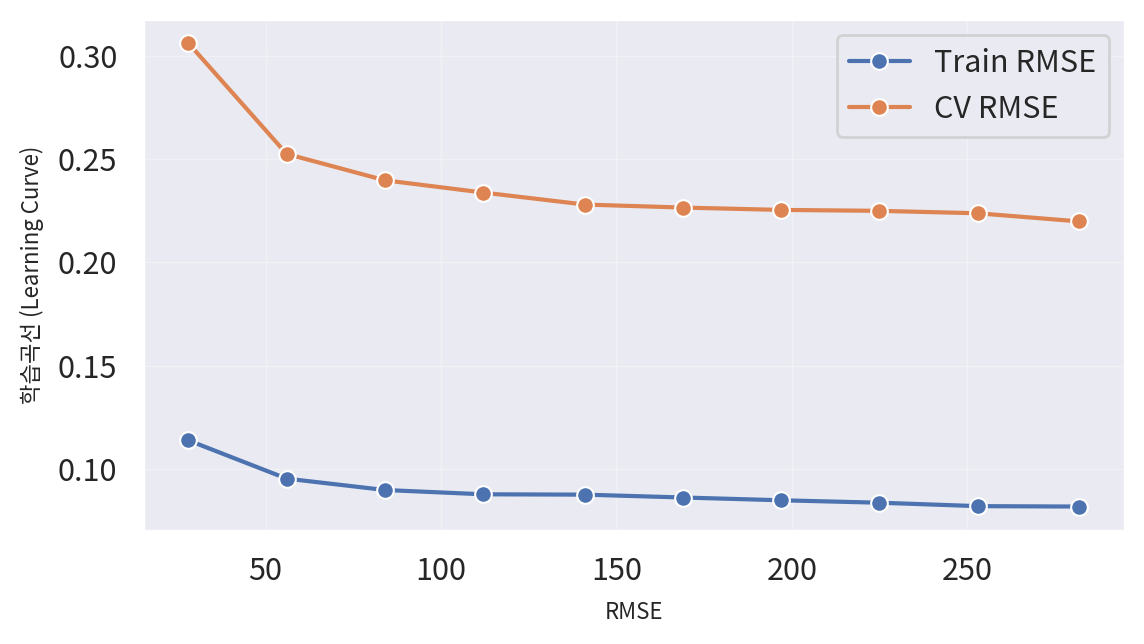

In [12]:
# ---------------------------
# 1) BaggingRegressor 정의
# ---------------------------
bagging = BaggingRegressor(
    estimator=loaded_model,
    bootstrap=True,
    random_state=52,
    n_jobs=-1,
)

# ---------------------------
# 2) Bagging 하이퍼파라미터 그리드
# ---------------------------
param_grid = {
    "n_estimators": [10, 30, 50, 100],
    "max_samples": [0.5, 0.7, 1.0],
    "max_features": [0.5, 0.7, 1.0],
}

# ---------------------------
# 3) GridSearchCV
# ---------------------------
bagging_gs = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

# ---------------------------
# 4) 학습
# ---------------------------
bagging_gs.fit(x_train, y_train)

best_bagging_model = bagging_gs.best_estimator_

hs_get_score_cv(best_bagging_model, x_train, y_train, x, y)


## #05. Bagging 결과 판단
### [1] 채택 여부 판단 기준

| 상태            | 권장 행동   |
| ------------- | ------- |
| 배깅 전 과대적합     | 배깅 시도 ⭕ |
| 배깅 후 안정화      | 유지 ⭕    |
| 배깅 후에도 과대적합   | 모델 전환 ⭕ |
| 배깅 후 CV 개선 없음 | 배깅 중단 ⭕ |



### [2] Bagging 후 성능 개선이 없을 경우

| 전환           | 이유                |
| ------------ | ----------------- |
| RandomForest | 배깅 + feature 무작위성 |
| Boosting     | 편향 감소에 특화         |


RandomForest를 사용한다는 것 자체가 D-Tree 모형에 대한 Bagging을 수행한다는 의미이고,
KNN은 베이스 모델 자체의 성능이 좋은 편이 아니기 때문에 실무 기준으로는 배깅을 따로 수행하지는 않는다.

